# Exercício:

## Importe o .csv utilizado no exercício 7 da aula 11 e instancie um objeto da classe DataFrame. Considere que não à uma ordem entre os genes.
Como inserir  na DataFrame uma tabela de frequência do número de caracteres no nome dos genes? Uma vez inserida, como obter um gráfico de barras deste dado?

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## 01 – Descreva o racional da sua resposta:

R.: <br>
Fará a importação do DataFrame utilizando pd.read_csv(). Antes de começar com a obtenção das frequências, já será feita a remoção (com .drop()) das colunas que não serão utilizadas (as que contém os dois primeiros caracteres, quantidade de 'a's e presença de caracteres 'hu'), para facilitar a análise e execução dos códigos (em vez de deixar para fazer no exercício 7 apenas). Neste caso, a frequência absoluta simples vai ser o próprio número de caracteres do gene, não necessitando calcular e adicionar em uma nova coluna. Somente será feita a mudança no nome da coluna de "Número de Caracteres" para "Frequência Absoluta Simples" (definirá com .columns = ["Novo Nome"]). Para adicionar a frequência relativa simples deverá instanciar uma nova coluna (df["Frequência Relativa Simples] = ) que seja equivalente a frequência absoluta simples dividida pelo total da frequência absoluta simples (.sum()). <br>
Para obter o gráfico de barras da frequência absoluta simples precisará utilizar a biblioteca seaborn, por meio de sns.barplot(), cujos parâmetros serão determinados entre os parênteses. Deverá determinar x igual ao index da DataFrame por .index (fará com que cada barra no eixo x seja equivalente a um gene); e o y à coluna da frequência absoluta simples indexando esta com .iloc[] (o eixo y será a própria frequência). <br> 
Para melhorar a apresentação deste gráfico (não é necessário), pode também definir o parâmetro hue como o próprio index da DataFrame e palette para colorir cada barra de uma cor diferente utilizando a sequência de cores definidas em palette (escolherá "colorblind"). Neste caso a legenda não será útil, podendo removê-la igualando o parâmetro legend a None. Por fim, pode definir o título com .set(title = "Nome do título"), e o título do eixo x com a biblioteca matplotlib na linha de código seguinte (com plt.xlabel("Nome do eixo x")). <br>
Pode usar plt.show() para retornar o gráfico apenas, excluindo informações da "setagem" do gráfico. <br>
Para obter o gráfico de barras da frequência relativa simples deverá fazer a mesma coisa que no anterior, apenas mudando o parâmetro y para o da coluna de frequência relativa simples (também podendo indexar com .iloc[]).

## 02 – Desenhe o fluxograma da resposta:

<img src="./img/Fluxograma02_13.png" width="400" />

## 03 – Escreva o programa em Python:

In [2]:
df = pd.read_csv('df_genes.csv', index_col='Unnamed: 0')

# Reorganizando o DataFrame antes do exercício 7 para facilitar a análise
df = df.drop(["Dois Primeiros Caracteres", "Quantidade de 'a's",
              "Presença de Caracteres 'hu'"], axis=1)
df

,Número de Caracteres
SRY,3
Cetn-1,6
PFR2,4
HER2,4
GFP,3


In [3]:
# Transformando o "Número de Caracteres" em frequência absoluta simples no DataFrame
df.columns = ["Frequência Absoluta Simples"]
df

,Frequência Absoluta Simples
SRY,3
Cetn-1,6
PFR2,4
HER2,4
GFP,3


In [4]:
# Adicionando a frequência relativa simples no DataFrame
df["Frequência Relativa Simples"] = df["Frequência Absoluta Simples"]/df[
    "Frequência Absoluta Simples"].sum()
df

,Frequência Absoluta Simples,Frequência Relativa Simples
SRY,3,0.15
Cetn-1,6,0.30
PFR2,4,0.20
HER2,4,0.20
GFP,3,0.15


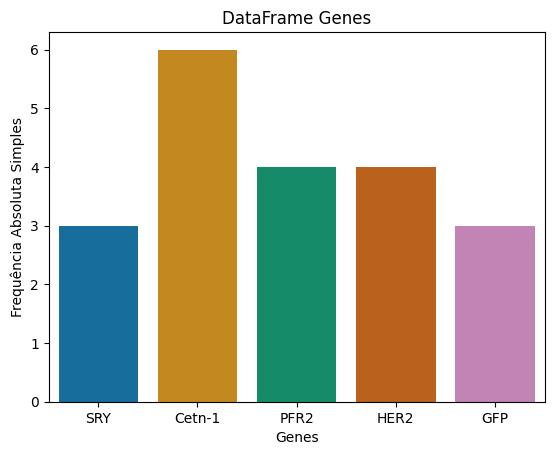

In [5]:
# Obtendo gráfico de barras a partir da frequência absoluta simples
sns.barplot(x=df.index, y=df.iloc[:,0],
            hue=df.index, palette='colorblind',
            legend=None).set(title="DataFrame Genes")
plt.xlabel("Genes")
plt.show()

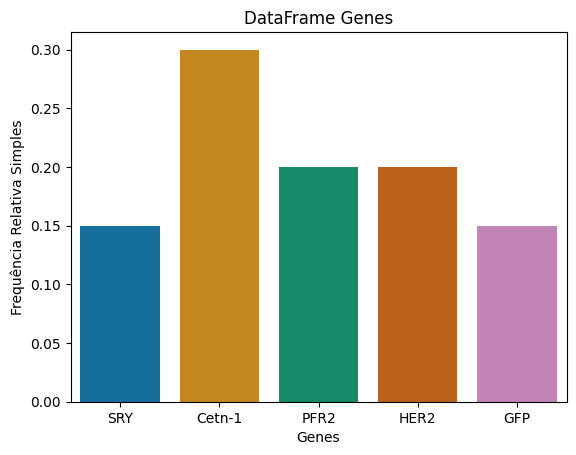

In [6]:
# Ou a partir da frequência relativa simples
sns.barplot(x=df.index, y=df.iloc[:,1],
            hue=df.index, palette='colorblind',
            legend=None).set(title="DataFrame Genes")
plt.xlabel("Genes")
plt.show()

## Importe o .csv utilizado no exercício 7 da aula 11 e instancie um objeto da classe DataFrame. Considere que à uma ordem entre os genes.
Como inserir  na DataFrame uma tabela de frequência do número de caracteres no nome dos genes? Uma vez inserida, como obter um gráfico de barras deste dado?

## 04 – Descreva o racional da sua resposta:

R.: <br>
Repetiria o que já foi feito e descrito nos exercícios 1 e 3 desta lista (exceto gerar os gráficos) para obter o DataFrame com a frequência absoluta e relativa simples. <br>
Como deverá considerar que há uma ordem entre os genes (ordinal), assumirá a ordem como SRY, Cetn-1, PFR2, HER2, GFP; não precisando fazer nenhuma alteração na organização do DataFrame (em relação à ordem das linhas). <br>
Para adicionar a frequência absoluta acumulada, basta instanciar uma nova coluna (df["Nova Coluna"] = ) que seja equivalente a coluna de frequência absoluta simples, realizando a soma acumulada dos valores com o método .cumsum(). Isto fará que haja a adição sequencial de cada valor, em que o seguinte na linha seja ele mesmo mais a soma de todos os valores anteriores. Isto deverá resultar na última linha (último valor) o total dos valores da frequência absoluta simples. <br>
Para adicionar a frequência relativa acumulada será utilizada uma lógica similar. Também instanciará uma nova coluna que será, no entanto; a soma acumulada (.cumsum()) dos valores da coluna de frequência relativa simples. Neste caso, haverá a soma sequencial da frequência relativa, em que na última linha obterá o total dos valores da frequência relativa simples. <br>
Para gerar o gráfico de barras da frequência absoluta acumulada utilizará a biblioteca seaborn por meio de sns.barplot(), onde entre os parênteses determinará os parâmetros para gerar o gráfico. Os parâmetros obrigatórios neste caso que deverão ser inseridos é o de x, equivalente ao index do DataFrame (fará com que cada barra do eixo x seja equivalente ao nome dos genes); e y à coluna da frequência absoluta acumulada (indexando por .iloc[], e fazendo com que o eixo y seja a frequência). Pode-se usar alguns parâmetros opcionais para melhorar a visualização do gráfico, como: hue (index do DataFrame) e palette (escolheu "colorblind") para que cada barra de gene tenha uma cor diferente; e legend = None, para remover a legenda que neste caso não está adicionando informação necessária. Poderá também terminar com .set(title = "Nome do título") para definir um título ao gráfico, e usando a biblioteca matplotlib o método plt.xlabel() para definir o título do eixo x. Finalmente, usando plt.show() para retornar o gráfico apenas, excluindo informações da "setagem" do gráfico. <br>
Para o gráfico de barras da frequência relativa acumulada deverá ser feita a mesma coisa, apenas alterando a indexação (.iloc[]) no parâmetro y para que seja referente à coluna de frequência relativa acumulada. 

## 05 – Desenhe o fluxograma da resposta:

<img src="./img/Fluxograma05_13.png" width="400" />

## 06 – Escreva o programa em Python:

In [7]:
# Importação e adição das frequências absoluta e relativa simples foram feitas no exercício anterior

In [8]:
# Adicionando a frequência absoluta acumulada no DataFrame
df["Frequência Absoluta Acumulada"] = df["Frequência Absoluta Simples"].cumsum()
df

,Frequência Absoluta Simples,Frequência Relativa Simples,Frequência Absoluta Acumulada
SRY,3,0.15,3
Cetn-1,6,0.30,9
PFR2,4,0.20,13
HER2,4,0.20,17
GFP,3,0.15,20


In [9]:
# Adicionando a frequência relativa acumulada no DataFrame
df["Frequência Relativa Acumulada"] = df["Frequência Relativa Simples"].cumsum()
df

,Frequência Absoluta Simples,Frequência Relativa Simples,Frequência Absoluta Acumulada,Frequência Relativa Acumulada
SRY,3,0.15,3,0.15
Cetn-1,6,0.30,9,0.45
PFR2,4,0.20,13,0.65
HER2,4,0.20,17,0.85
GFP,3,0.15,20,1.00


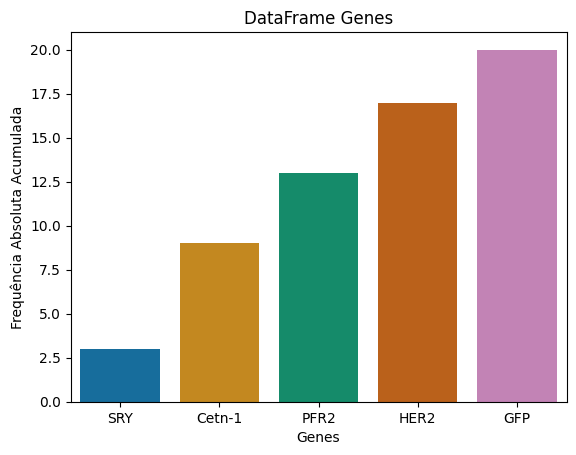

In [10]:
# Obtendo gráfico de barras a partir da frequência absoluta acumulada
sns.barplot(x=df.index, y=df.iloc[:,2],
            hue=df.index, palette='colorblind',
            legend=None).set(title="DataFrame Genes")
plt.xlabel("Genes")
plt.show()

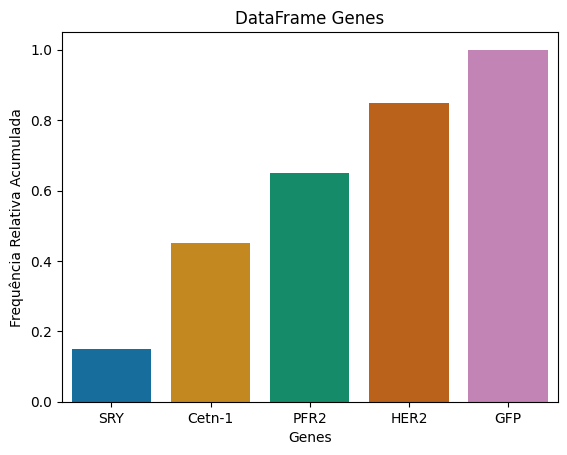

In [11]:
# Ou a partir da frequência relativa acumulada
sns.barplot(x=df.index, y=df.iloc[:,3],
            hue=df.index, palette='colorblind',
            legend=None).set(title="DataFrame Genes")
plt.xlabel("Genes")
plt.show()

## 07 – Reorganize a DataFrame, removendo as colunas contendo os dois primeiros caracteres, o número de caracter 'a', e a presença de 'hu', dos genes. Renomeie as colunas de acordo com as informações. Adicione uma coluna com a informação de 'Amostra 1'.

In [12]:
# DataFrame já reorganizada no início da lista de exercícios (exercício 3)
df

,Frequência Absoluta Simples,Frequência Relativa Simples,Frequência Absoluta Acumulada,Frequência Relativa Acumulada
SRY,3,0.15,3,0.15
Cetn-1,6,0.30,9,0.45
PFR2,4,0.20,13,0.65
HER2,4,0.20,17,0.85
GFP,3,0.15,20,1.00


In [13]:
# Adicionando nova coluna de amostras
df["Amostras"] = "Amostra 1"
df

,Frequência Absoluta Simples,Frequência Relativa Simples,Frequência Absoluta Acumulada,Frequência Relativa Acumulada,Amostras
SRY,3,0.15,3,0.15,Amostra 1
Cetn-1,6,0.30,9,0.45,Amostra 1
PFR2,4,0.20,13,0.65,Amostra 1
HER2,4,0.20,17,0.85,Amostra 1
GFP,3,0.15,20,1.00,Amostra 1


In [14]:
# Colocando total
df_tot = df.copy()
df_tot.loc["Total"] = df_tot.iloc[:,0:2].sum()
df_tot.iloc[-1,-1] = "Amostra 1"
df_tot

,Frequência Absoluta Simples,Frequência Relativa Simples,Frequência Absoluta Acumulada,Frequência Relativa Acumulada,Amostras
SRY,3.0,0.15,3.0,0.15,Amostra 1
Cetn-1,6.0,0.30,9.0,0.45,Amostra 1
PFR2,4.0,0.20,13.0,0.65,Amostra 1
HER2,4.0,0.20,17.0,0.85,Amostra 1
GFP,3.0,0.15,20.0,1.00,Amostra 1
Total,20.0,1.00,NaN,NaN,Amostra 1


## 08 – Usando a função randint(), da classe random do módulo numpy (np.random.randint(1,10,5)), instancie objeto da classe numpy array. Calcule as frequências desta nova amostra, considerando que à uma ordem entre os genes. Insira na DataFrame este objeto como "Amostra 2".

In [15]:
# Gerando o array
np.random.seed(42)
a2_arr = np.random.randint(1,10,5).reshape(5,1)

# Criando o DataFrame e adicionando as colunas
df_2 = pd.DataFrame(a2_arr, index=df.index, columns=["Frequência Absoluta Simples"])
df_2["Frequência Relativa Simples"] = df_2["Frequência Absoluta Simples"]/df_2["Frequência Absoluta Simples"].sum()
df_2["Frequência Absoluta Acumulada"] = df_2["Frequência Absoluta Simples"].cumsum()
df_2["Frequência Relativa Acumulada"] = df_2["Frequência Relativa Simples"].cumsum()
df_2["Amostras"] = "Amostra 2"
df = pd.concat([df, df_2], axis = 0)
df

,Frequência Absoluta Simples,Frequência Relativa Simples,Frequência Absoluta Acumulada,Frequência Relativa Acumulada,Amostras
SRY,3,0.150000,3,0.150000,Amostra 1
Cetn-1,6,0.300000,9,0.450000,Amostra 1
PFR2,4,0.200000,13,0.650000,Amostra 1
HER2,4,0.200000,17,0.850000,Amostra 1
GFP,3,0.150000,20,1.000000,Amostra 1
SRY,7,0.225806,7,0.225806,Amostra 2
Cetn-1,4,0.129032,11,0.354839,Amostra 2
PFR2,8,0.258065,19,0.612903,Amostra 2
HER2,5,0.161290,24,0.774194,Amostra 2
GFP,7,0.225806,31,1.000000,Amostra 2


## 09 – Repita o exercício 8, inserindo na DataFrame as replicas "Amostra 3“, "Amostra 4“, "Amostra 5“ e "Amostra 6".

In [16]:
# Amostra 3, 4, 5 e 6
x=0
while x < 4:
    ax_arr = np.random.randint(1,10,5).reshape(-1,1)
    df_x = pd.DataFrame(ax_arr, index=df.index[:5], columns=["Frequência Absoluta Simples"])
    df_x["Frequência Relativa Simples"] = df_x["Frequência Absoluta Simples"]/df_x[
        "Frequência Absoluta Simples"].sum()
    df_x["Frequência Absoluta Acumulada"] = df_x["Frequência Absoluta Simples"].cumsum()
    df_x["Frequência Relativa Acumulada"] = df_x["Frequência Relativa Simples"].cumsum()
    df_x["Amostras"] = "Amostra " + str(x+3)
    df = pd.concat([df, df_x], axis = 0)
    x=x+1
df

,Frequência Absoluta Simples,Frequência Relativa Simples,Frequência Absoluta Acumulada,Frequência Relativa Acumulada,Amostras
SRY,3,0.150000,3,0.150000,Amostra 1
Cetn-1,6,0.300000,9,0.450000,Amostra 1
PFR2,4,0.200000,13,0.650000,Amostra 1
HER2,4,0.200000,17,0.850000,Amostra 1
GFP,3,0.150000,20,1.000000,Amostra 1
SRY,7,0.225806,7,0.225806,Amostra 2
Cetn-1,4,0.129032,11,0.354839,Amostra 2
PFR2,8,0.258065,19,0.612903,Amostra 2
HER2,5,0.161290,24,0.774194,Amostra 2
GFP,7,0.225806,31,1.000000,Amostra 2


## 10 – Obtenha dos seus dados o gráfico abaixo, adicionando 3 replicas.

In [17]:
df["Réplica"] = "Réplica 1"

# Criando nóvas réplicas
    # Réplica 2
x=0
while x < 6:
    ax_arr = np.random.randint(1,10,5).reshape(-1,1)
    df_x = pd.DataFrame(ax_arr, index=df.index[:5], columns=["Frequência Absoluta Simples"])
    df_x["Frequência Relativa Simples"] = df_x["Frequência Absoluta Simples"]/df_x[
        "Frequência Absoluta Simples"].sum()
    df_x["Frequência Absoluta Acumulada"] = df_x["Frequência Absoluta Simples"].cumsum()
    df_x["Frequência Relativa Acumulada"] = df_x["Frequência Relativa Simples"].cumsum()
    df_x["Amostras"] = "Amostra " + str(x+1)
    df = pd.concat([df, df_x], axis = 0)
    x=x+1
    # Adicionando "Réplica 2" na coluna de Réplicas
df.fillna("Réplica 2", inplace=True)
df.tail() # Confirmar se adicionou no final

,Frequência Absoluta Simples,Frequência Relativa Simples,Frequência Absoluta Acumulada,Frequência Relativa Acumulada,Amostras,Réplica
SRY,4,0.181818,4,0.181818,Amostra 6,Réplica 2
Cetn-1,2,0.090909,6,0.272727,Amostra 6,Réplica 2
PFR2,6,0.272727,12,0.545455,Amostra 6,Réplica 2
HER2,6,0.272727,18,0.818182,Amostra 6,Réplica 2
GFP,4,0.181818,22,1.000000,Amostra 6,Réplica 2


In [18]:
# Criando nóvas réplicas
    # Réplica 3
x=0
while x < 6:
    ax_arr = np.random.randint(1,10,5).reshape(-1,1)
    df_x = pd.DataFrame(ax_arr, index=df.index[:5], columns=["Frequência Absoluta Simples"])
    df_x["Frequência Relativa Simples"] = df_x["Frequência Absoluta Simples"]/df_x[
        "Frequência Absoluta Simples"].sum()
    df_x["Frequência Absoluta Acumulada"] = df_x["Frequência Absoluta Simples"].cumsum()
    df_x["Frequência Relativa Acumulada"] = df_x["Frequência Relativa Simples"].cumsum()
    df_x["Amostras"] = "Amostra " + str(x+1)
    df = pd.concat([df, df_x], axis = 0)
    x=x+1
    # Adicionando "Réplica 2" na coluna de Réplicas
df.fillna("Réplica 3", inplace=True)
df.tail() # Confirmar se adicionou no final

,Frequência Absoluta Simples,Frequência Relativa Simples,Frequência Absoluta Acumulada,Frequência Relativa Acumulada,Amostras,Réplica
SRY,3,0.157895,3,0.157895,Amostra 6,Réplica 3
Cetn-1,3,0.157895,6,0.315789,Amostra 6,Réplica 3
PFR2,1,0.052632,7,0.368421,Amostra 6,Réplica 3
HER2,5,0.263158,12,0.631579,Amostra 6,Réplica 3
GFP,7,0.368421,19,1.000000,Amostra 6,Réplica 3


In [19]:
df.info() # Confirmando adição

<class 'pandas.core.frame.DataFrame'>
Index: 90 entries, SRY to GFP
Data columns (total 6 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Frequência Absoluta Simples    90 non-null     int64  
 1   Frequência Relativa Simples    90 non-null     float64
 2   Frequência Absoluta Acumulada  90 non-null     int64  
 3   Frequência Relativa Acumulada  90 non-null     float64
 4   Amostras                       90 non-null     object 
 5   Réplica                        90 non-null     object 
dtypes: float64(2), int64(2), object(2)
memory usage: 4.9+ KB


In [20]:
df.value_counts("Amostras")

Amostras
Amostra 1    15
Amostra 2    15
Amostra 3    15
Amostra 4    15
Amostra 5    15
Amostra 6    15
Name: count, dtype: int64

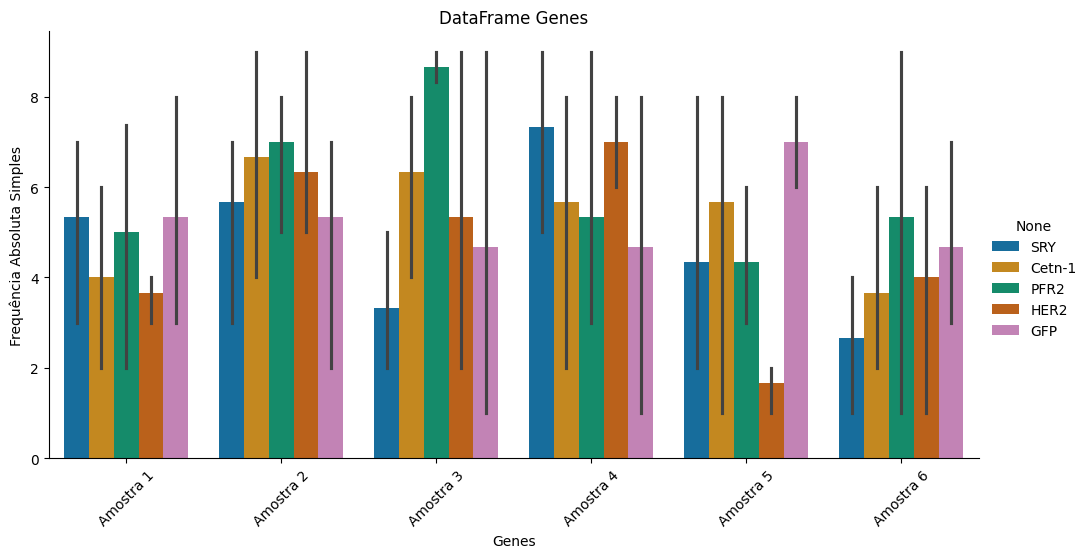

In [21]:
# Obtendo gráfico de barras a partir da frequência absoluta simples
sns.catplot(x=df["Amostras"], y=df["Frequência Absoluta Simples"],
    kind="bar", hue=df.index,
    palette='colorblind', aspect=2).set(title="DataFrame Genes")
plt.xlabel("Genes")
plt.xticks(rotation=45) # Rotacionar 45 graus para ficar melhor visualizável
plt.show()

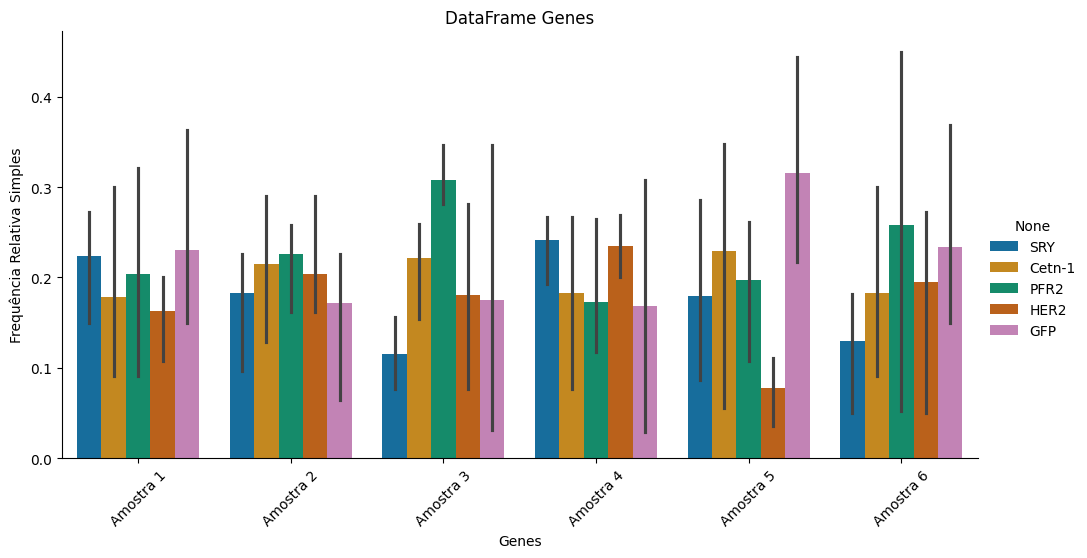

In [22]:
# Obtendo gráfico de barras a partir da frequência relativa simples
sns.catplot(x=df["Amostras"], y=df["Frequência Relativa Simples"],
    kind="bar", hue=df.index,
    palette='colorblind', aspect=2).set(title="DataFrame Genes")
plt.xlabel("Genes")
plt.xticks(rotation=45) # Rotacionar 45 graus para ficar melhor visualizável
plt.show()

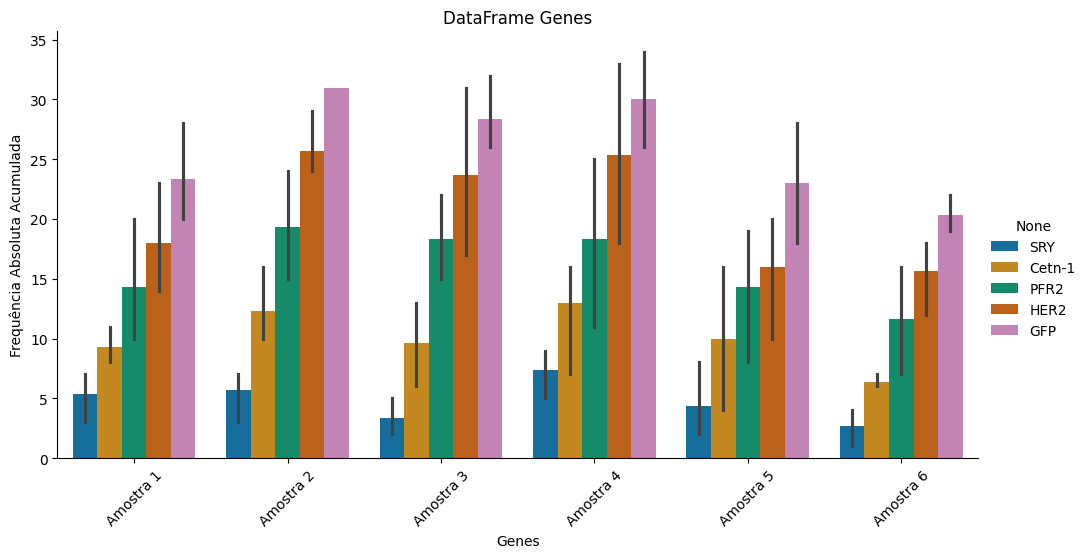

In [23]:
# Obtendo gráfico de barras a partir da frequência absoluta acumulada
sns.catplot(x=df["Amostras"], y=df["Frequência Absoluta Acumulada"],
    kind="bar", hue=df.index,
    palette='colorblind', aspect=2).set(title="DataFrame Genes")
plt.xlabel("Genes")
plt.xticks(rotation=45) # Rotacionar 45 graus para ficar melhor visualizável
plt.show()

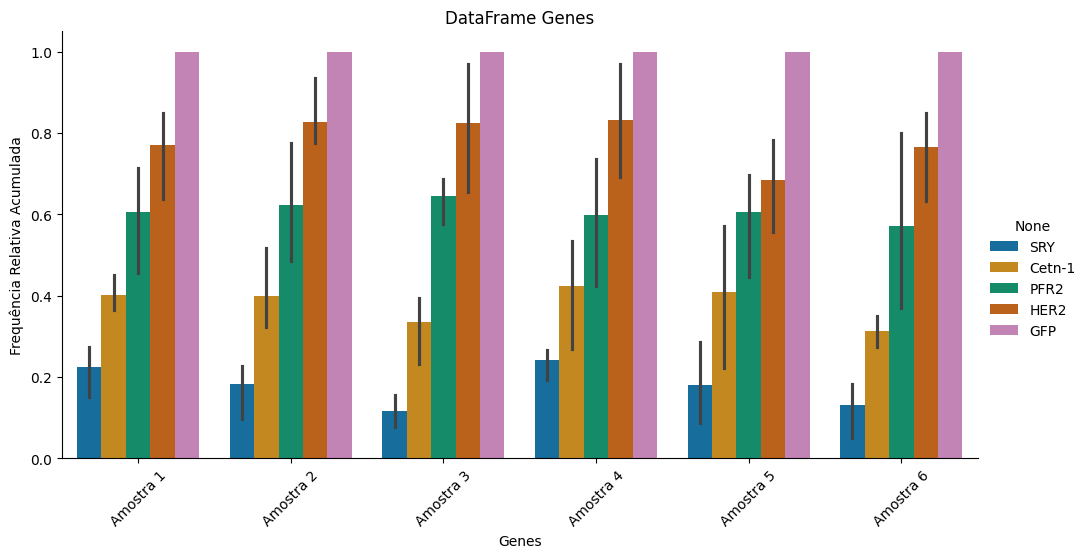

In [24]:
# Obtendo gráfico de barras a partir da frequência absoluta acumulada
sns.catplot(x=df["Amostras"], y=df["Frequência Relativa Acumulada"],
    kind="bar", hue=df.index,
    palette='colorblind', aspect=2).set(title="DataFrame Genes")
plt.xlabel("Genes")
plt.xticks(rotation=45) # Rotacionar 45 graus para ficar melhor visualizável
plt.show()